# Visión por computadora

## TP 3 

Tomás Abraham

A2602

In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Encontrar el logotipo de la gaseosa dentro de las imagenes provistas en Material_TPs/TP3/images a partir del template Material/TPs/TP3/template

El template que debo encontrar en las imagenes es el siguiente

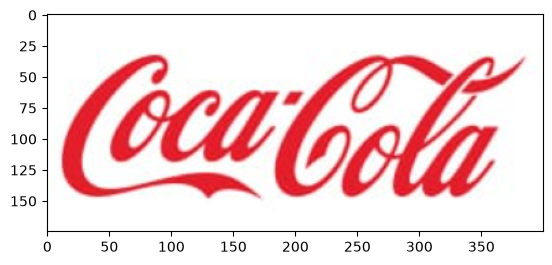

In [32]:
template = cv2.imread("template/pattern.png")

template = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

plt.figure("Template")
plt.imshow(template)
plt.show()

Las imagenes en las que debo buscar son las siguientes

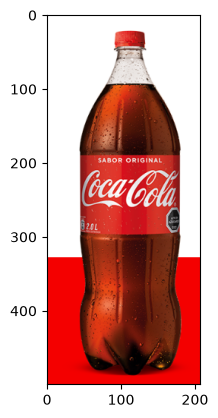

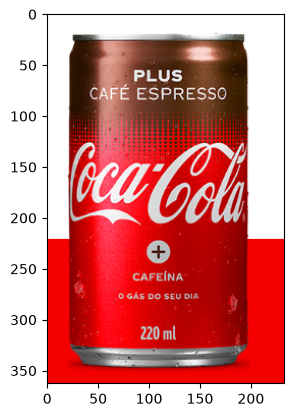

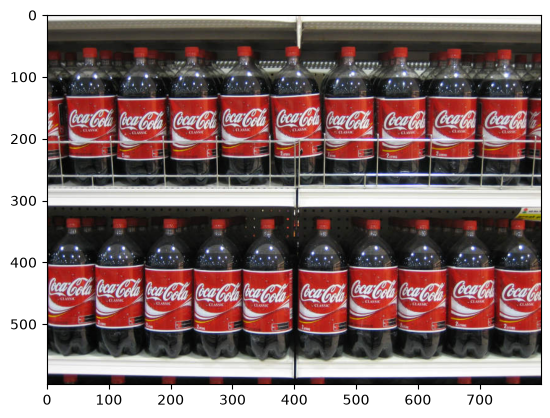

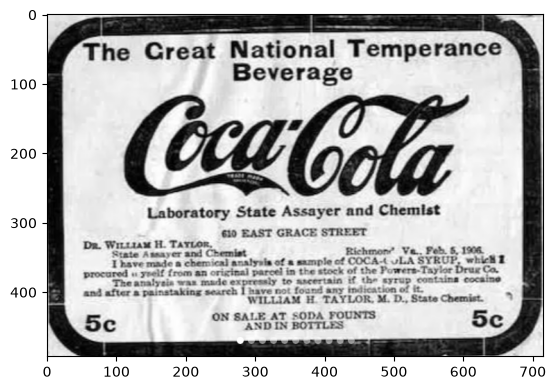

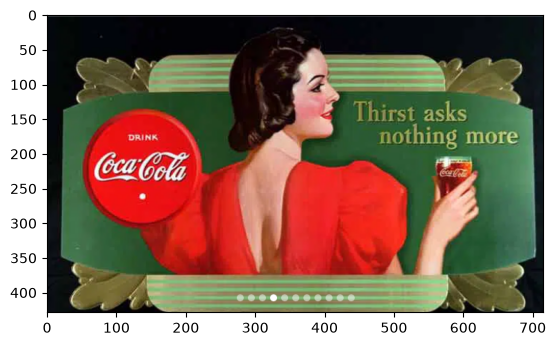

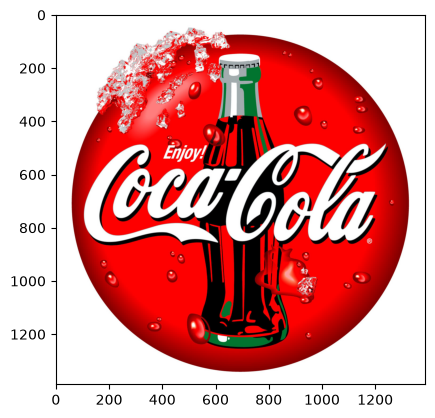

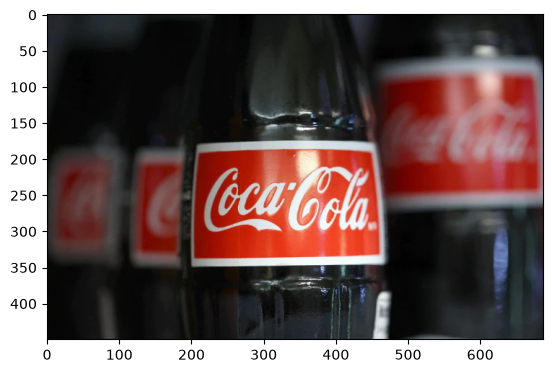

In [33]:
img0 = cv2.imread('images/coca_logo_1.png')
img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)

img1 = cv2.imread('images/coca_logo_2.png')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread('images/coca_multi.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img3 = cv2.imread('images/coca_retro_1.png')
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

img4 = cv2.imread('images/coca_retro_2.png')
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

img5 = cv2.imread('images/COCA-COLA-LOGO.jpg')
img5 = cv2.cvtColor(img5, cv2.COLOR_BGR2RGB)

img6 = cv2.imread('images/logo_1.png')
img6 = cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)


imgs = [img0, img1, img2, img3, img4, img5, img6]
i = 0
for img in imgs:

    nombreImg = "Imagen " + str(i)
    
    plt.figure(nombreImg)
    plt.imshow(img)
    plt.show()

    i = i + 1 
    

In [42]:
import cv2
import numpy as np


def busqueda_template_v1(img, template, threshold=0.25, Log=False):
    img_out = img.copy()

    # Convierto a escala de grises
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

    # Extraer bordes usando Canny
    img_canny = cv2.Canny(img_gray, 50, 200)
    template_canny = cv2.Canny(template_gray, 50, 200)

    if Log:
        cv2.imshow("Gray", img_gray)
        cv2.imshow("template gray", template_gray)
        cv2.imshow("Img Canny", img_canny)
        cv2.imshow("Template Canny", template_canny)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    # CORRECCIÓN 1: shape devuelve (alto, ancho) -> (h, w)
    h_t, w_t = template_canny.shape
    h_i, w_i = img_canny.shape

    best_match = None

    for scale in np.linspace(0.1, 1.0, 40):
        w_scaled = int(w_t * scale)
        h_scaled = int(h_t * scale)

        if w_scaled > w_i or h_scaled > h_i or w_scaled < 10 or h_scaled < 10:
            continue

        # Redimensionar (cv2.resize toma tuple de (ancho, alto))
        resized_template = cv2.resize(
            template_canny, (w_scaled, h_scaled), interpolation=cv2.INTER_AREA
        )

        # CORRECCIÓN 2: Usar TM_CCOEFF_NORMED en lugar de TM_CCORR
        res = cv2.matchTemplate(
            img_canny, resized_template, cv2.TM_CCOEFF_NORMED
        )
        _, max_val, _, max_loc = cv2.minMaxLoc(res)

        if best_match is None or max_val > best_match[0]:
            x1, y1 = max_loc
            x2, y2 = x1 + w_scaled, y1 + h_scaled
            best_match = (max_val, (x1, y1, x2, y2))

    if best_match is not None and best_match[0] >= threshold:
        score, (x1, y1, x2, y2) = best_match
        cv2.rectangle(img_out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        print(f"Coincidencia encontrada con score: {score:.2f}")
        return img_out, (x1, y1, x2 - x1, y2 - y1)

    print("No se encontró ninguna coincidencia por encima del umbral.")
    return img_out, None
   

Coincidencia encontrada con score: 0.35


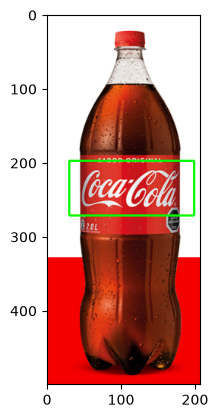

In [43]:
# prueba

imgBusqueda0, _ = busqueda_template_v1(imgs[0], template, 0.1, True) 

plt.figure("Busqueda 0")
plt.imshow(imgBusqueda0)
plt.show()